# Detección de anomalías — Isolation Forest

**Obligatorio AIOps — PharmaGo — Objetivo 5: Detección de anomalías**

**Isolation Forest** aísla observaciones construyendo árboles aleatorios: las anomalías requieren menos particiones para quedar aisladas, por lo que obtienen *path lengths* más cortos.

El entrenamiento es **no supervisado**: el modelo no usa etiquetas. La columna `is_anomaly` se reserva sólo para *evaluar* la calidad al final.

> **Dataset:** se usa un dataset sintético reproducible de métricas operacionales (`data/operational_metrics_sample.csv`). Para usar el dataset real de los docentes, reemplazar el archivo o cambiar `DATA_PATH` en la celda de carga.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Carga de datos

*(Punto único a cambiar cuando llegue el dataset real.)*

In [2]:
DATA_PATH = 'data/operational_metrics_sample.csv'
df = pd.read_csv(DATA_PATH)
FEATURES = ['cpu_usage', 'memory_usage', 'request_latency_ms', 'error_rate', 'request_rate', 'network_io_mbps']
print('Filas:', len(df), '| Columnas:', list(df.columns))
df.head()

Filas: 2000 | Columnas: ['cpu_usage', 'memory_usage', 'request_latency_ms', 'error_rate', 'request_rate', 'network_io_mbps', 'is_anomaly']


,cpu_usage,memory_usage,request_latency_ms,error_rate,request_rate,network_io_mbps,is_anomaly
0,0.402449,0.579019,80.405426,0.012021,129.471923,2.404904,0
1,0.415101,0.488487,90.723802,0.011588,99.028597,2.149632,0
2,0.371608,0.629292,67.633532,0.008356,85.822153,1.588414,0
3,0.514824,0.662847,73.573343,0.010249,134.383683,2.575285,0
4,0.415936,0.539865,72.327820,0.007110,170.759325,3.442168,0


## 2. Análisis exploratorio (EDA)

In [3]:
display(df[FEATURES].describe().round(3))
print('\nBalance de clases (solo para referencia/evaluacion):')
print(df['is_anomaly'].value_counts())
print('Proporcion de anomalias: {:.1%}'.format(df['is_anomaly'].mean()))

,cpu_usage,memory_usage,request_latency_ms,error_rate,request_rate,network_io_mbps
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,0.375,0.592,191.836,0.032,128.953,2.267
std,0.149,0.099,557.637,0.107,86.382,0.760
min,0.058,0.382,37.828,0.000,0.130,0.000
25%,0.297,0.533,66.916,0.007,101.658,1.922
50%,0.353,0.579,73.638,0.010,119.742,2.339
75%,0.409,0.627,80.745,0.014,136.489,2.757
max,0.999,1.000,3996.970,0.799,897.105,4.347



Balance de clases (solo para referencia/evaluacion):
is_anomaly
0    1900
1     100
Name: count, dtype: int64
Proporcion de anomalias: 5.0%


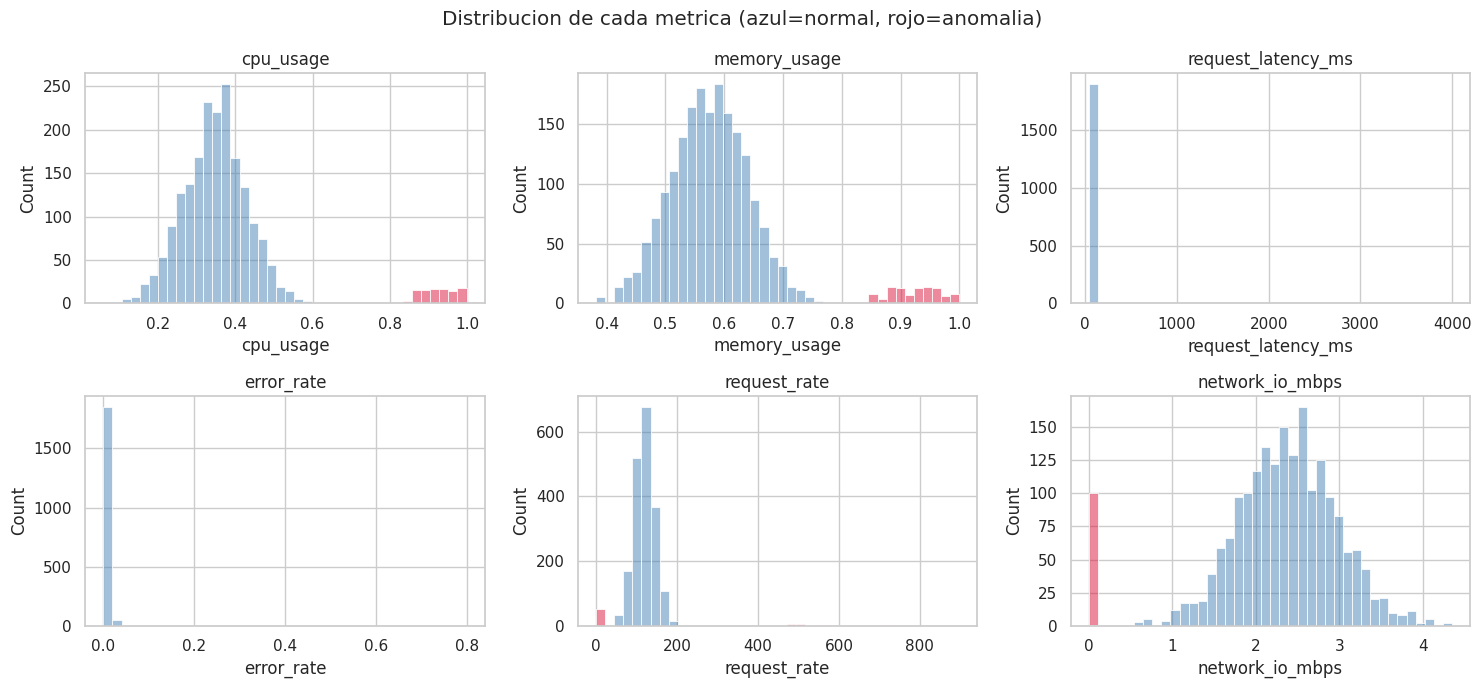

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.histplot(data=df, x=col, hue='is_anomaly', bins=40,
                 ax=ax, palette={0: 'steelblue', 1: 'crimson'}, legend=False)
    ax.set_title(col)
fig.suptitle('Distribucion de cada metrica (azul=normal, rojo=anomalia)')
fig.tight_layout()
plt.show()

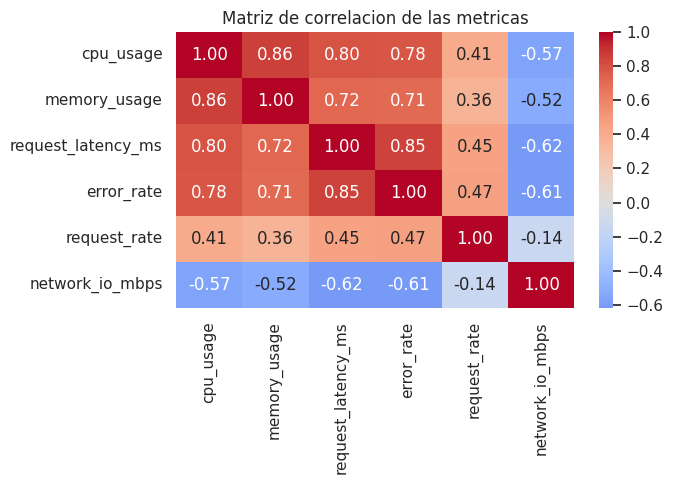

In [5]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlacion de las metricas')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

Se separan features de la etiqueta y se estandarizan (media 0, desvío 1) con `StandardScaler`, requisito para modelos sensibles a la escala como SVM.

In [6]:
X = df[FEATURES].values
y = df['is_anomaly'].values  # solo para evaluar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('X_scaled shape:', X_scaled.shape)

X_scaled shape: (2000, 6)


## 4. Entrenamiento — Isolation Forest

`contamination=0.05` indica la proporción esperada de anomalías.

In [7]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(n_estimators=200, contamination=0.05,
                        random_state=RANDOM_STATE)
model.fit(X_scaled)
# score: invertimos decision_function para que MAYOR = mas anomalo
anomaly_score = -model.decision_function(X_scaled)

## 5. Predicción y evaluación

El modelo devuelve `+1` (normal) / `-1` (anomalía). Se convierte a `0/1` y se compara contra `is_anomaly`.

El *score* se obtiene de `-decision_function` (mayor = más anómalo).

In [8]:
pred = model.predict(X_scaled)
pred_anomaly = (pred == -1).astype(int)
print(classification_report(y, pred_anomaly,
      target_names=['normal', 'anomalia']))
auc = roc_auc_score(y, anomaly_score)
print('ROC AUC (anomaly_score): {:.3f}'.format(auc))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      1900
    anomalia       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC AUC (anomaly_score): 1.000


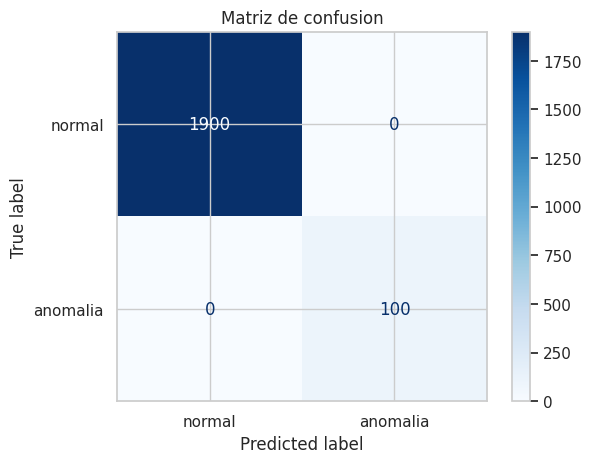

In [9]:
cm = confusion_matrix(y, pred_anomaly)
ConfusionMatrixDisplay(cm, display_labels=['normal', 'anomalia']).plot(cmap='Blues')
plt.title('Matriz de confusion')
plt.show()

## 6. Visualización en 2D (PCA)

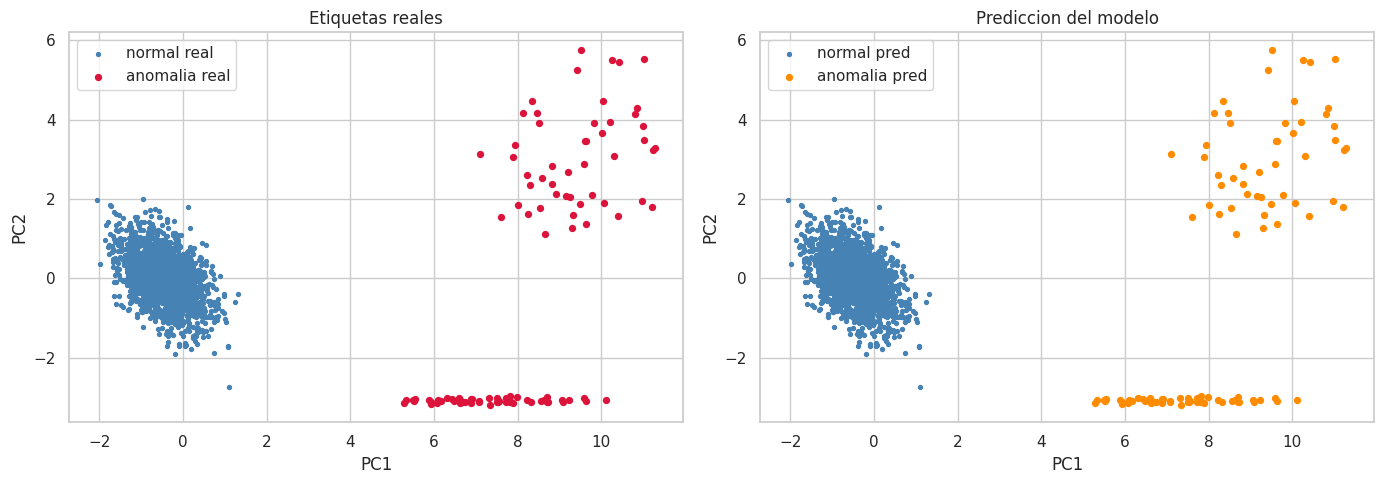

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(X_2d[y==0, 0], X_2d[y==0, 1], s=8, c='steelblue', label='normal real')
ax[0].scatter(X_2d[y==1, 0], X_2d[y==1, 1], s=18, c='crimson', label='anomalia real')
ax[0].set_title('Etiquetas reales'); ax[0].legend()
ax[1].scatter(X_2d[pred_anomaly==0, 0], X_2d[pred_anomaly==0, 1], s=8, c='steelblue', label='normal pred')
ax[1].scatter(X_2d[pred_anomaly==1, 0], X_2d[pred_anomaly==1, 1], s=18, c='darkorange', label='anomalia pred')
ax[1].set_title('Prediccion del modelo'); ax[1].legend()
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()

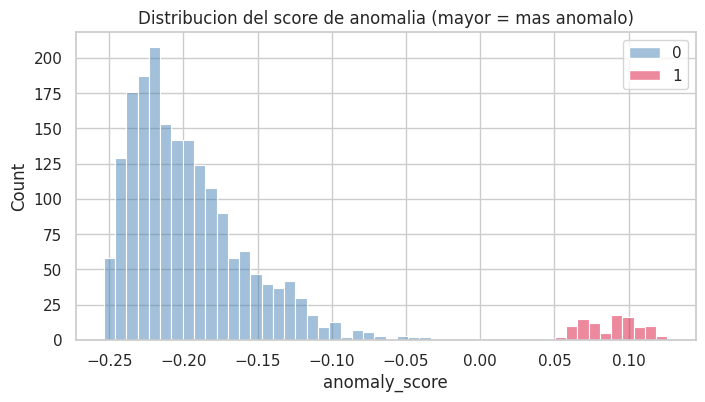

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(x=anomaly_score, hue=y, bins=50,
             palette={0: 'steelblue', 1: 'crimson'})
plt.title('Distribucion del score de anomalia (mayor = mas anomalo)')
plt.xlabel('anomaly_score')
plt.show()

## 7. Conclusiones

- Isolation Forest detecta las anomalías inyectadas con buen recall sin usar etiquetas en el entrenamiento.
- Es eficiente y escala bien; el hiperparámetro clave es `contamination`.
- En producción, este modelo se alimentaría con las métricas reales recolectadas por Prometheus (CPU, memoria, latencia, error rate, red) para alertar sobre comportamiento anómalo.
- **Comparación con One-Class SVM**: ver el notebook `svm_anomaly_detection.ipynb`.